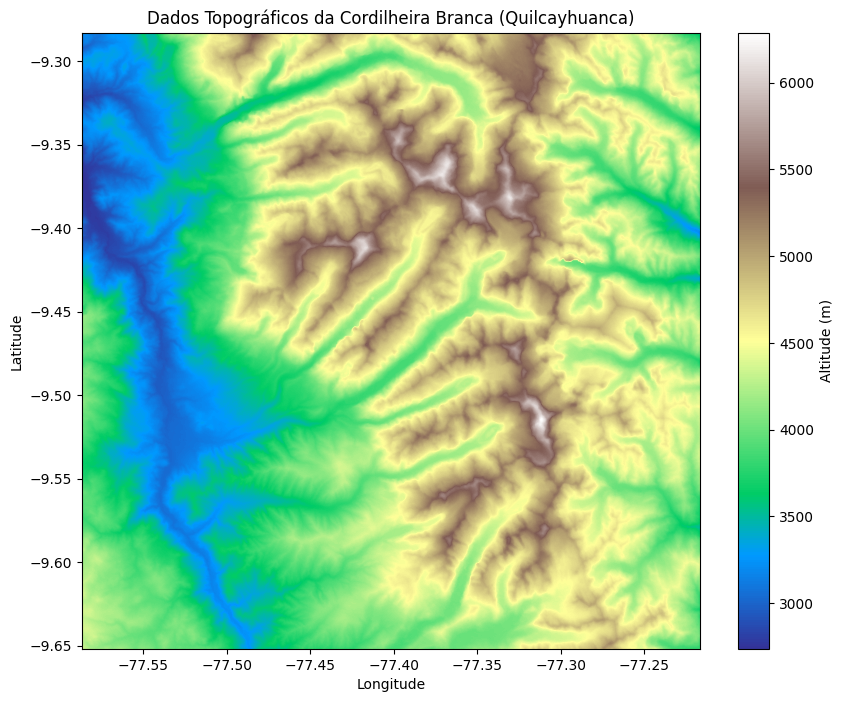

In [8]:
import rasterio
import matplotlib.pyplot as plt

# Abrindo o arquivo TIFF
with rasterio.open('/home/matheus/Documentos/GitHub/LACRIO/Analises/Mapa/Quilcayhuanca_sub_cuenca.tif') as src:
    # Lendo a primeira banda (geralmente a única banda em dados de elevação)
    data = src.read(1)
    # Obtendo os limites espaciais do arquivo
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

# Configurando a figura
plt.figure(figsize=(10, 8))
# Usando uma paleta de cores adequada para topografia, como 'terrain'
plt.imshow(data, cmap='terrain', extent=extent)
plt.colorbar(label='Altitude (m)')
plt.title('Dados Topográficos da Cordilheira Branca (Quilcayhuanca)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


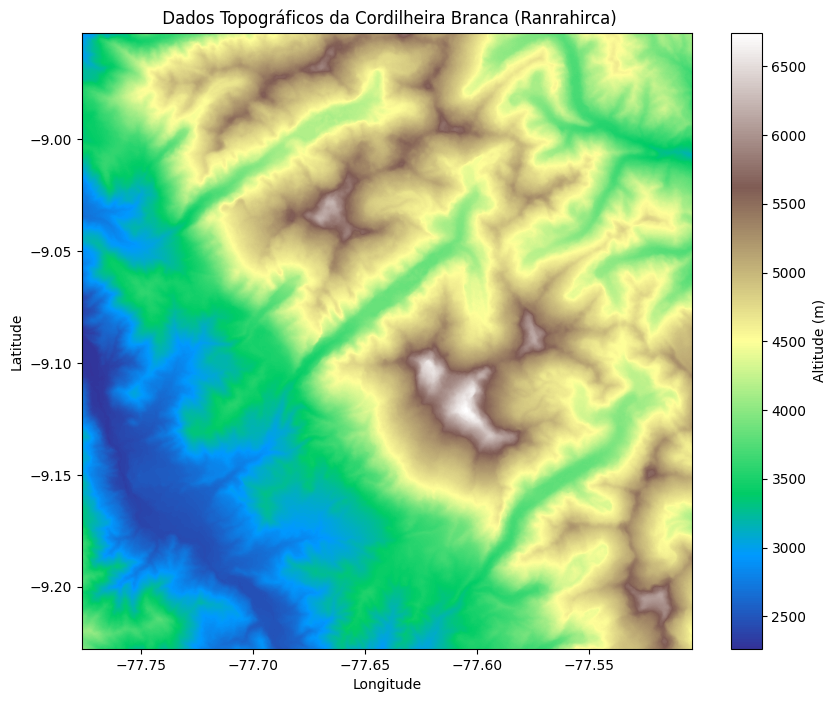

In [9]:
import rasterio
import matplotlib.pyplot as plt

# Abrindo o arquivo TIFF
with rasterio.open('/home/matheus/Documentos/GitHub/LACRIO/Analises/Mapa/Ranrahirca.tif') as src:
    # Lendo a primeira banda (geralmente a única banda em dados de elevação)
    data = src.read(1)
    # Obtendo os limites espaciais do arquivo
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

# Configurando a figura
plt.figure(figsize=(10, 8))
# Usando uma paleta de cores adequada para topografia, como 'terrain'
plt.imshow(data, cmap='terrain', extent=extent)
plt.colorbar(label='Altitude (m)')
plt.title(' Dados Topográficos da Cordilheira Branca (Ranrahirca)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

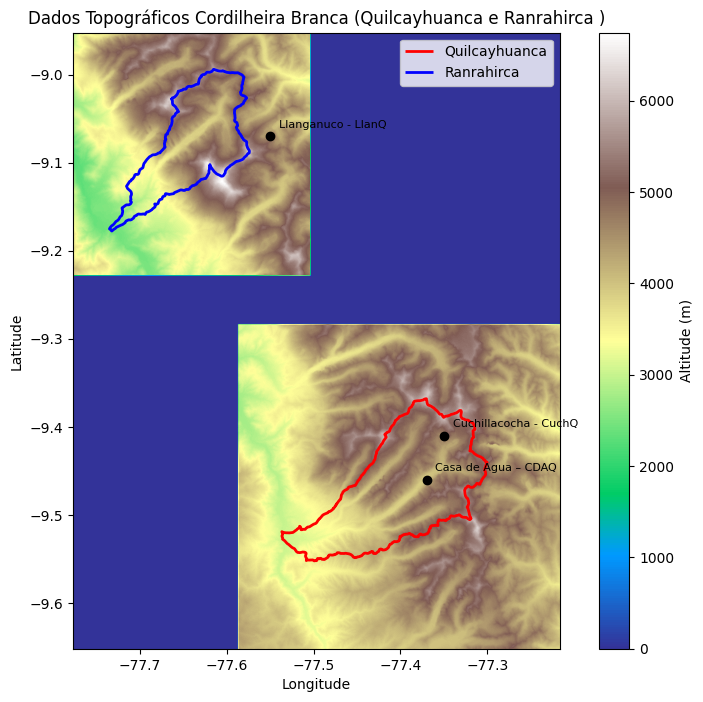

In [12]:
import rasterio
from rasterio.merge import merge
import matplotlib.pyplot as plt
import geopandas as gpd

# Caminhos dos arquivos TIFF
tif1 = '/home/matheus/Documentos/GitHub/LACRIO/Analises/Mapa/Quilcayhuanca_sub_cuenca.tif'
tif2 = '/home/matheus/Documentos/GitHub/LACRIO/Analises/Mapa/Ranrahirca.tif'

# Abrindo os arquivos e armazenando em uma lista
src_files = [rasterio.open(tif1), rasterio.open(tif2)]

# Realizando o merge (mosaico) dos rasters
mosaic, out_trans = merge(src_files)

# Fechando os arquivos abertos
for src in src_files:
    src.close()

# Selecionando a primeira banda do mosaico
mosaic_data = mosaic[0]

# Calculando os limites (extent) da imagem usando a transformação affine
left = out_trans.c
top = out_trans.f
right = left + mosaic_data.shape[1] * out_trans.a
bottom = top + mosaic_data.shape[0] * out_trans.e
extent = [left, right, bottom, top]

# Lendo os shapefiles
shp_quil = gpd.read_file('/home/matheus/Documentos/GitHub/LACRIO/Analises/Mapa/Quilcayhuanca_sub_cuenca.shp')
shp_ran = gpd.read_file('/home/matheus/Documentos/GitHub/LACRIO/Analises/Mapa/Ranrahirca_sub_cuenca.shp')

# EXEMPLO: se o seu raster e shapefile estiverem em EPSG:4326 e as estações também:
# Caso contrário, faça a reprojeção dos shapefiles:
# shp_quil = shp_quil.to_crs(epsg=4326)
# shp_ran = shp_ran.to_crs(epsg=4326)

# Lista de estações: (Nome, Latitude, Longitude)
# (IMPORTANTE: verifique se a ordem Lat/Lon coincide com a projeção do seu raster)
stations = [
    ('Cuchillacocha - CuchQ', -9.41, -77.35),
    ('Llanganuco - LlanQ',   -9.07, -77.55),
    ('Casa de Agua – CDAQ', -9.46, -77.37 )
]

# Criando a figura
fig, ax = plt.subplots(figsize=(10, 8))

# Plotando o mosaico
cax = ax.imshow(mosaic_data, cmap='terrain', extent=extent)

# Plotando os contornos dos shapefiles
shp_quil.boundary.plot(ax=ax, edgecolor='red', linewidth=2, label='Quilcayhuanca')
shp_ran.boundary.plot(ax=ax, edgecolor='blue', linewidth=2, label='Ranrahirca')

# Plotando as estações
for station_name, lat, lon in stations:
    # Em mapas, a convenção é (x=Longitude, y=Latitude).
    ax.plot(lon, lat, 'ko')  # 'ko' = marcador circular (o) preto (k)
    # Adicionando rótulo (nome) da estação próximo ao ponto
    ax.text(lon + 0.01, lat + 0.01, station_name, fontsize=8, color='black')

# Ajustando colorbar e rótulos
plt.colorbar(cax, label='Altitude (m)')
plt.title('Dados Topográficos Cordilheira Branca (Quilcayhuanca e Ranrahirca )')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()
